# Milestone 4: Baseline Model, Pipeline Development, and TF Meeting

<b>Project Group 2:</b> <i> Max Bahar, Mila Ivanovska, Stefan Chu, Ted McCulloch</i>


#### Effective Notebook Submission Guidelines:

[] Start with a clear, concise problem statement.

[] Organize logically with headings and subheadings; table of contents are required!

[] Explain code, choices, and results using comments and markdown.

[] Use clear, well-labeled visualizations with descriptive captions.

[] Maintain clean, readable code with structured processes.

[] Ensure reproducibility: the notebook should run error-free and document data sources. No errors. No warning messages.


## Notes from Pavlos OH

Use **Mixture of Experts**! Use a meta model to aggregate the predictions from the first model and predict the class using a second model. 

We have $N$ states that consist of multiple states from $M$ objects.

We create a first model that predicts all $N$ states.

For each object, we choose $K$ observation/state predictions (will need to be padded/truncated for objects with less/more than $K$ observation/state predictions). 

Then, we create a second model that aggregates the $K$ observations for each of the $M$ objects to generate a class prediction for each object.

Graphically, for $x_t^{(i)}$, the state in time $t$ for observation $i$:
$$
    x^{(i)}_t \rightarrow \text{MODEL 1} \rightarrow \{ p(y|x_1^{(i)}), \dots, p(y|x_t^{(i)}) \} \rightarrow \text{META MODEL} \rightarrow \hat{y}
$$

We must be very careful about creating validation sets, making sure that these are defined correctly.

Pavlos mentioned that the meta model could be a RNN, specifying a max length for the specific fold/window of predictions/data to use by the meta model.

Meta model could also utilize gates to learn which specific inputs they should prioritize.

Keywords to look for: ,ixture models, stacking models, blending models.

If Pavlos were designing it, the architecture would look like:
$$
    x_t^{(i)} \rightarrow \text{NN}_1 \rightarrow \{ p(y|x_1^{(i)}), \dots, p(y|x_t^{(i)}) \} \rightarrow \text{NN}_2 \rightarrow \hat{y}
$$
And the loss from NN_1 and NN_2 are combined somehow to train the model simultaneously.

In [17]:

# imports
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# utilities
import utils.preprocessing as pp
import utils.visualization as viz
import utils.time as tu

## 1. Introduction and Problem Statement

Currently, there are around 30,000 publicly cataloged objects in Earth's orbit. In reality, the number is likely much higher, as 1) not every piece of debris in orbit has a known position or identification number,  2) not every payload is publicly disclosed by the government of origin, and  3) different organizations report varying figures.

Traditionally, space objects are classified into three categories:

1. **Payloads**: Functional spacecraft or satellites launched into space to perform specific missions, such as communication, navigation, or research. The total count in orbit is around 14,000, but the number still active or operational is estimated to be about 11,600.

2. **Rocket Bodies**: Parts of launch vehicles (e.g., stages) that delivered payloads to orbit but remain in space as non-operational objects.

3. **Debris**: Non-functional fragments or objects in space, including pieces from collisions, explosions, or decommissioned satellites, that no longer serve any purpose.

While all objects are subject to the same orbital perturbations, the nature of each object type should produce identifiable patterns in their orbital elements. For example, active payloads will conduct station-keeping maneuvers to maintain their desired orbits. Geostationary satellites, for instance, have orbital periods of nearly exactly 1,440 minutes—matching Earth's rotation. However, if they stop performing station-keeping maneuvers, their orbits will begin to drift due to various perturbative forces (gravity, drag, radiation pressure, solar activity, etc.). Likewise, although both are essentially space junk, debris and rocket bodies should also exhibit distinct orbital behaviors due to differences in their average size, mass, and origin.


### _Our question is:_



**Given a history of orbital states, can we predict with confidence the object's type?**

Initially, we aimed to use two years of orbital data, removing time-dependent elements and identifiers to train our model to perform type classification. However, we are now pivoting to leverage the time dimension, using not a stationary set of elements, but rather a time-separated element histories as input to our three-type classification model. This pivot allows us to utilize more complex modeleling classes and techniques. 

Our EDA has confirmed that there are differences in orbital elements amongst object types, which are most pronounced in inclination, eccentritiy, apogee, and argument of perigee. Moreover, by examing the correlations between our features, we identified several meaningful patterns (and noted the ones which were trivial/meaningless). 


## 2.  Comprehensive EDA Review


[] Summarize key findings from EDA, focusing on how these insights informed feature engineering and model selection.

[] Detail the feature engineering process, including transformations, encoding, or selection techniques, with justifications rooted in EDA.

[] Include visualizations that support analytical decisions, linking back to the problem statement and project goals.

In [18]:
X_numerical = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER'] 
X_numerical_revised = X_numerical + ['MEAN_MOTION_1ST_DER', 'B_STAR']
response = 'TYPE'

df_final = pd.read_csv('../data/large/final_df_v1.csv') # <-- Run Part 1 of DataConsolidation.ipynb to produce file


In [19]:
df_payload = df_final[df_final['TYPE'] == 'PAYLOAD']
df_rb = df_final[df_final['TYPE'] == 'ROCKET BODY']
df_debris = df_final[df_final['TYPE'] == 'DEBRIS']  


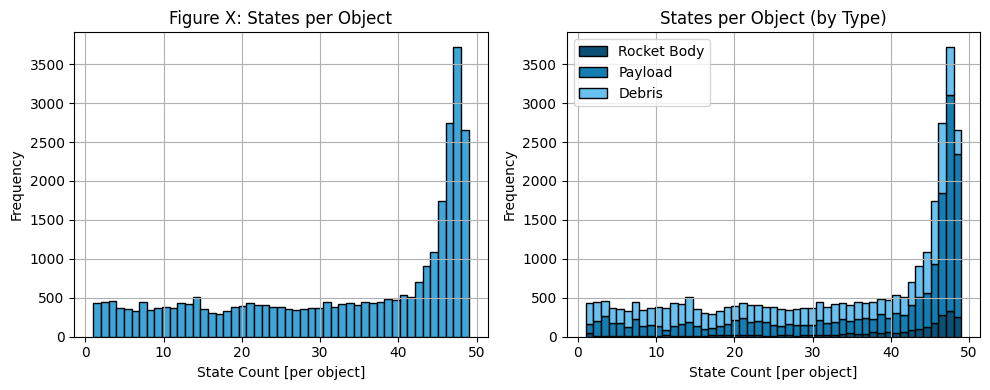

In [20]:


fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].hist(df_final['NUMBER'].value_counts().values, bins=49, edgecolor='black', color='#3FA6DA')
axs[0].set_title("Figure X: States per Object")
axs[0].set_xlabel("State Count [per object]")
axs[0].set_ylabel("Frequency")
axs[0].grid(True)

axs[1].hist([df_rb['NUMBER'].value_counts().values,
             df_payload['NUMBER'].value_counts().values,
             df_debris['NUMBER'].value_counts().values], 
            bins=49, edgecolor='black', stacked=True, 
            color=["#0C5174", "#147EB3", "#68C1EE"], 
            label=['Rocket Body', 'Payload', 'Debris'])
axs[1].set_title("States per Object (by Type)")
axs[1].set_xlabel("State Count [per object]")
axs[1].set_ylabel("Frequency")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [21]:
df_epoch_min_max = df_final.groupby('NUMBER')['EPOCH'].agg(['min', 'max']).reset_index()
df_epoch_min_max['min_datetime'] = df_epoch_min_max['min'].apply(tu.year_doy_to_datetime)
df_epoch_min_max['max_datetime'] = df_epoch_min_max['max'].apply(tu.year_doy_to_datetime)
df_epoch_min_max

,NUMBER,min,max,min_datetime,max_datetime
0,5,23074.130708,25074.298269,2023-03-15 03:08:13.188480,2025-03-15 07:09:30.415680
1,11,23074.509605,25074.189782,2023-03-15 12:13:49.911744,2025-03-15 04:33:17.176896
2,12,23074.278815,25074.143389,2023-03-15 06:41:29.609952,2025-03-15 03:26:28.815648
3,16,23074.443615,25074.636965,2023-03-15 10:38:48.364512,2025-03-15 15:17:13.811424
4,20,23074.333729,25074.195186,2023-03-15 08:00:34.178688,2025-03-15 04:41:04.034112
...,...,...,...,...,...
30490,63153,25074.513083,25074.513083,2025-03-15 12:18:50.365152,2025-03-15 12:18:50.365152
30491,63204,25074.412897,25074.412897,2025-03-15 09:54:34.267968,2025-03-15 09:54:34.267968
30492,63205,25074.038727,25074.038727,2025-03-15 00:55:45.999840,2025-03-15 00:55:45.999840
30493,63206,25074.006400,25074.006400,2025-03-15 00:09:12.999744,2025-03-15 00:09:12.999744


/var/folders/hx/dyff0fq1083gs4x9d1pt4rrw0000gn/T/ipykernel_6681/989834906.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45);


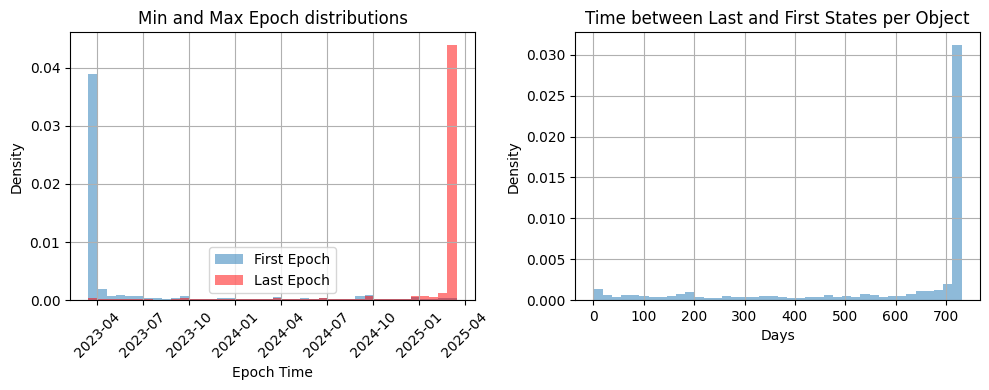

In [22]:
b = 40
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(df_epoch_min_max['min_datetime'], bins=b, alpha=0.5, label='First Epoch', density=True)
ax1.hist(df_epoch_min_max['max_datetime'], bins=b, alpha=0.5, label='Last Epoch', density=True, color='red')

ax1.set_xlabel('Epoch Time')
ax1.set_ylabel('Density')
ax1.set_title('Min and Max Epoch distributions')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45);
ax1.grid(True)
ax1.legend()

ax2.hist((df_epoch_min_max['max_datetime'] - df_epoch_min_max['min_datetime']).dt.days,
         bins=b, alpha=0.5, density=True)

ax2.set_xlabel('Days')
ax2.set_ylabel('Density')
ax2.set_title('Time between Last and First States per Object')
ax2.grid(True)

plt.tight_layout()
plt.show()


## 3. Baseline Model Selection and Justification

[] Explain the choice of your baseline model, considering simplicity, interpretability, and relevance.

[] Detail the training process, including preprocessing, parameters, and metrics used for evaluation.

[] Present initial results, discussing alignment with expectations and project objectives.

In [23]:
def preprocess_data(df_to_use, X_numerical, response):
    label_encoder = LabelEncoder()
    scaler = StandardScaler()

    X = df_to_use[X_numerical]
    y = df_to_use[response]
    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded,
        test_size=0.2,
        random_state=101,
        stratify=y_encoded
    )

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    return  X_train, X_test, y_train, y_test, label_encoder, scaler

In [24]:
X_train, X_test, y_train, y_test, label_encoder, scaler = preprocess_data(df_final, X_numerical, response)

In [25]:
# df_smote = pp.create_smote_df(df_final)
df_smote = pd.read_csv('../data/large/df_smote_v1.csv')  # <-- Run Part 2 of DataConsolidation.ipynb to produce file

## 4. Results Interpretation and Analysis

[] Analyze the baseline model’s performance, using appropriate metrics and visualizations.

[] Assess strengths and weaknesses of the model, proposing improvements for the next iteration.

## 5. Final Model Pipeline Setup

[] Outline steps for a pipeline for your final model, describing each component from data preprocessing to evaluation.

[] Document assumptions, parameter choices, and preliminary tuning considerations.


### Usage of ChatGPT

1. used it to help manipulate dataframe values relative to 'NUMBER' grouping
